# CSCI 5527 Deep Learning Project
## Team: Beep Learning

### Get the Data from FER2013

In [72]:
%pip install kaggle
%pip install kagglehub
%pip install torch
%pip install torchvision
%pip install optuna

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [73]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

import kagglehub
import optuna
from optuna.trial import TrialState

# Add project path
sys.path.append(r'd:\UMN Couses\CSCI 5527 Deep Learning\Project\csci5527-project')
from fer_dataset import FERDataset

print("✓ All libraries imported successfully!")
print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

# Define device for GPU/CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✓ Device set to: {device}")

✓ All libraries imported successfully!
Python: c:\Users\1\AppData\Local\Programs\Python\Python312\python.exe
Torch version: 2.11.0+cu128
Torch CUDA version: 12.8
CUDA available: True
GPU: NVIDIA GeForce GTX 1650

✓ Device set to: cuda


## Import Required Libraries

In [74]:
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\1\.cache\kagglehub\datasets\msambare\fer2013\versions\1


In [75]:
#!git clone https://github.com/RohitPoduval1/csci5527-project.git

In [76]:
# Verify FERDataset import
print("FERDataset imported successfully!")
print(f"Dataset classes available: {len(FERDataset.__doc__)} emotion types")

FERDataset imported successfully!
Dataset classes available: 161 emotion types


### Load the dataset and split it

In [77]:
# Get the path from kagglehub (you already have this in 'path' variable)
fer_path = path

# Create train and test datasets with transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale images
])

train_dataset = FERDataset(fer_path, split='train', transforms=transform)
test_dataset = FERDataset(fer_path, split='test', transforms=transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Emotion classes: {train_dataset.classes}")

Train dataset size: 28709
Test dataset size: 7178
Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [78]:
# Optimize DataLoaders for GPU
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,  # Parallel data loading
    pin_memory=True  # Faster GPU transfer
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"✓ GPU-optimized DataLoaders created")
print(f"  - num_workers: 4 (parallel loading)")
print(f"  - pin_memory: True (faster transfer to GPU)")

✓ GPU-optimized DataLoaders created
  - num_workers: 4 (parallel loading)
  - pin_memory: True (faster transfer to GPU)


In [79]:
class VanillaCNN(nn.Module):
    """Simple CNN for facial emotion recognition"""
    def __init__(self, num_classes=7, dropout_rate=0.25, fc_dropout=0.5):
        super(VanillaCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.relu4 = nn.ReLU(inplace=True)
        self.dropout4 = nn.Dropout(fc_dropout)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.relu5 = nn.ReLU(inplace=True)
        self.dropout5 = nn.Dropout(fc_dropout)
        
        self.fc3 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = self.fc1(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.dropout4(x)
        
        x = self.fc2(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.dropout5(x)
        
        x = self.fc3(x)
        return x

# Initialize model and move to device
model = VanillaCNN(num_classes=len(train_dataset.classes))
model = model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Model parameters: 1,307,591
VanillaCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p

### Train Vanilla CNN (Baseline)

In [80]:
def train_model(model, train_loader, test_loader, num_epochs=50, lr=0.001, patience=10, verbose=True, use_amp=True):
    """
    Train the model and return training history
    
    Args:
        model: PyTorch model to train
        train_loader: Training data loader
        test_loader: Validation data loader
        num_epochs: Number of epochs to train
        lr: Learning rate
        patience: Early stopping patience
        verbose: Print progress
        use_amp: Use mixed precision training (faster on GPU)
    
    Returns:
        dict: Training history with losses and accuracies
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    scaler = torch.cuda.amp.GradScaler() if use_amp and torch.cuda.is_available() else None
    
    best_val_acc = 0
    patience_counter = 0
    best_model_wts = model.state_dict().copy()
    
    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accs': [],
        'val_accs': [],
        'best_val_acc': 0
    }
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass with mixed precision
            if use_amp and scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                # Backward pass with scaled loss
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            # Statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        history['train_losses'].append(train_loss)
        history['train_accs'].append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                # Use mixed precision for inference too
                if use_amp and torch.cuda.is_available():
                    with torch.cuda.amp.autocast():
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss /= len(test_loader)
        val_acc = 100 * val_correct / val_total
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)
        
        scheduler.step(val_loss)
        
        if verbose and (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {train_acc:.2f}% ({train_loss:.4f}) | Val: {val_acc:.2f}% ({val_loss:.4f})")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_wts)
    history['best_val_acc'] = best_val_acc
    
    # Clean up GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return history

print("✓ Training function defined with GPU optimizations!")

✓ Training function defined with GPU optimizations!


## Training Execution

### Training Function

## Training

In [81]:
# Train vanilla CNN with default hyperparameters
model_vanilla = VanillaCNN(num_classes=len(train_dataset.classes), dropout_rate=0.25, fc_dropout=0.5)
model_vanilla = model_vanilla.to(device)

print("🚀 Training Vanilla CNN with GPU optimizations...")
print(f"   Device: {device}")
history_vanilla = train_model(
    model_vanilla, 
    train_loader, 
    test_loader, 
    num_epochs=30, 
    lr=0.001, 
    patience=10,
    use_amp=True  # Enable mixed precision training on GPU
)

print(f"\n✓ Training Complete!")
print(f"  Best Validation Accuracy: {history_vanilla['best_val_acc']:.2f}%")
print(f"  Final Training Accuracy: {history_vanilla['train_accs'][-1]:.2f}%")
print(f"  Final Validation Accuracy: {history_vanilla['val_accs'][-1]:.2f}%")

🚀 Training Vanilla CNN with GPU optimizations...
   Device: cuda


C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp and torch.cuda.is_available() else None
C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [5/30] | Train: 52.90% (1.2470) | Val: 56.12% (1.1411)
Epoch [10/30] | Train: 58.79% (1.1017) | Val: 60.14% (1.0440)
Epoch [15/30] | Train: 63.05% (1.0060) | Val: 61.56% (1.0307)
Epoch [20/30] | Train: 65.61% (0.9211) | Val: 61.98% (1.0364)
Epoch [25/30] | Train: 68.31% (0.8582) | Val: 63.46% (1.0082)
Epoch [30/30] | Train: 70.99% (0.7933) | Val: 64.04% (1.0217)

✓ Training Complete!
  Best Validation Accuracy: 64.11%
  Final Training Accuracy: 70.99%
  Final Validation Accuracy: 64.04%


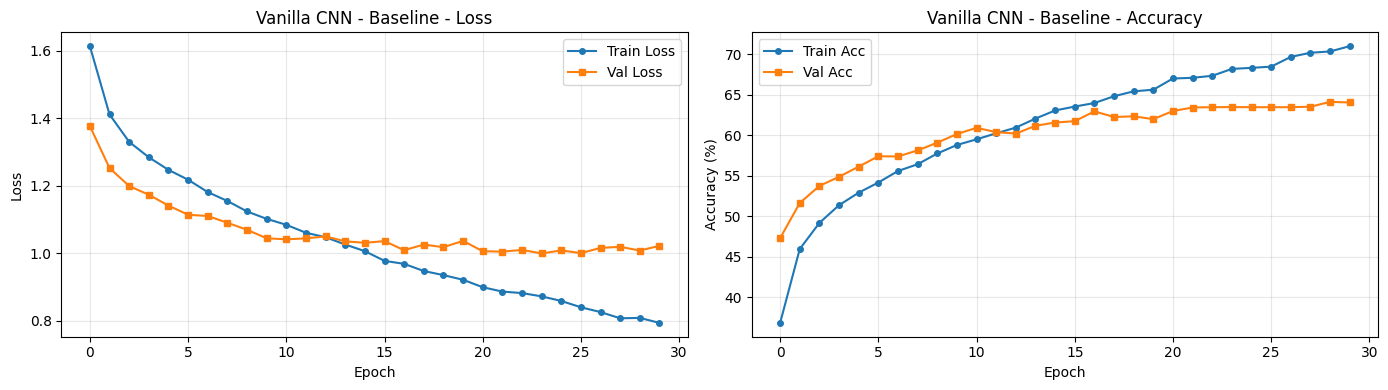

In [82]:
def plot_history(history, title="Training History"):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Loss plot
    ax1.plot(history['train_losses'], label='Train Loss', marker='o', markersize=4)
    ax1.plot(history['val_losses'], label='Val Loss', marker='s', markersize=4)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(history['train_accs'], label='Train Acc', marker='o', markersize=4)
    ax2.plot(history['val_accs'], label='Val Acc', marker='s', markersize=4)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot vanilla CNN results
plot_history(history_vanilla, "Vanilla CNN - Baseline")

## Hyperparameter Optimization with Optuna

In [ ]:
# Define Optuna objective and run the study

def objective(trial):
    """Optuna objective function for hyperparameter tuning."""
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    fc_dropout = trial.suggest_float('fc_dropout', 0.3, 0.7)

    model = VanillaCNN(
        num_classes=len(train_dataset.classes),
        dropout_rate=dropout_rate,
        fc_dropout=fc_dropout
    ).to(device)

    history = train_model(
        model,
        train_loader,
        test_loader,
        num_epochs=30,
        lr=lr,
        patience=5,
        verbose=False,
        use_amp=True
    )
    return history['best_val_acc']

print("✓ Optuna objective function defined!")

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
print("🚀 Starting Optuna hyperparameter optimization (20 trials)...")
study.optimize(objective, n_trials=20, show_progress_bar=True)

best_trial = study.best_trial
print("\n" + "="*60)
print("OPTUNA OPTIMIZATION RESULTS")
print("="*60)
print(f"\nBest Trial: #{best_trial.number}")
print(f"Best Accuracy: {best_trial.value:.2f}%")
print("\nBest Hyperparameters:")
for key, value in best_trial.params.items():
    if key == 'lr':
        print(f"  • {key}: {value:.6f}")
    else:
        print(f"  • {key}: {value:.4f}")

[I 2026-04-16 11:00:40,910] A new study created in memory with name: no-name-6c2d26a4-7160-4408-9e8d-cbd1f53b3970


✓ Optuna objective function defined!
🚀 Starting Optuna hyperparameter optimization (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp and torch.cuda.is_available() else None
C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[I 2026-04-16 11:34:06,062] Trial 0 finished with value: 58.37280579548621 and parameters: {'lr': 0.0005611516415334506, 'dropout_rate': 0.4802857225639665, 'fc_dropout': 0.592797576724562}. Best is trial 0 with value: 58.37280579548621.
[I 2026-04-16 11:59:49,110] Trial 1 finished with value: 64.02897743103928 and parameters: {'lr': 0.0015751320499779737, 'dropout_rate': 0.1624074561769746, 'fc_dropout': 0.362397808134481}. Best is trial 1 with value: 64.02897743103928.
[I 2026-04-16 12:32:12,670] Trial 2 finished with value: 56.82641404290889 and parameters: {'lr': 0.00013066739238053285, 'dropout_rate': 0.4464704583099741, 'fc_dropout': 0.5404460046972834}. Best is trial 1 with value: 64.02897743103928.
[I 2026-04-16 12:55:25,799] Trial 3 finished with value: 60.9640568403455 and parameters: {'lr': 0.0026070247583707684, 'dropout_rate': 0.10823379771832098, 'fc_dropout': 0.6879639408647977}. Best is trial 1 with value: 64.02897743103928.
[I 2026-04-16 13:27:06,897] Trial 4 finished 

In [84]:
# Train final model with best hyperparameters
best_params = best_trial.params
print(f"\n🚀 Training Final Model with Best Optuna Hyperparameters...")

model_best = VanillaCNN(
    num_classes=len(train_dataset.classes),
    dropout_rate=best_params['dropout_rate'],
    fc_dropout=best_params['fc_dropout']
).to(device)

history_best = train_model(
    model_best,
    train_loader,
    test_loader,
    num_epochs=30,
    lr=best_params['lr'],
    patience=10,
    use_amp=True
)

print(f"\n✓ Final Training Complete!")
print(f"  Best Validation Accuracy: {history_best['best_val_acc']:.2f}%")
print(f"  Final Training Accuracy: {history_best['train_accs'][-1]:.2f}%")
print(f"  Final Validation Accuracy: {history_best['val_accs'][-1]:.2f}%")


🚀 Training Final Model with Best Optuna Hyperparameters...


C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if use_amp and torch.cuda.is_available() else None
C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\1\AppData\Local\Temp\ipykernel_7272\2485328875.py:89: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [5/30] | Train: 54.32% (1.2032) | Val: 57.01% (1.1236)
Epoch [10/30] | Train: 61.19% (1.0324) | Val: 60.25% (1.0506)
Epoch [15/30] | Train: 66.09% (0.9045) | Val: 62.48% (1.0217)
Epoch [20/30] | Train: 71.84% (0.7632) | Val: 63.62% (1.0465)
Epoch [25/30] | Train: 75.15% (0.6687) | Val: 64.14% (1.0805)
Epoch [30/30] | Train: 78.17% (0.5965) | Val: 63.65% (1.1201)

✓ Final Training Complete!
  Best Validation Accuracy: 64.14%
  Final Training Accuracy: 78.17%
  Final Validation Accuracy: 63.65%


### Compare Models

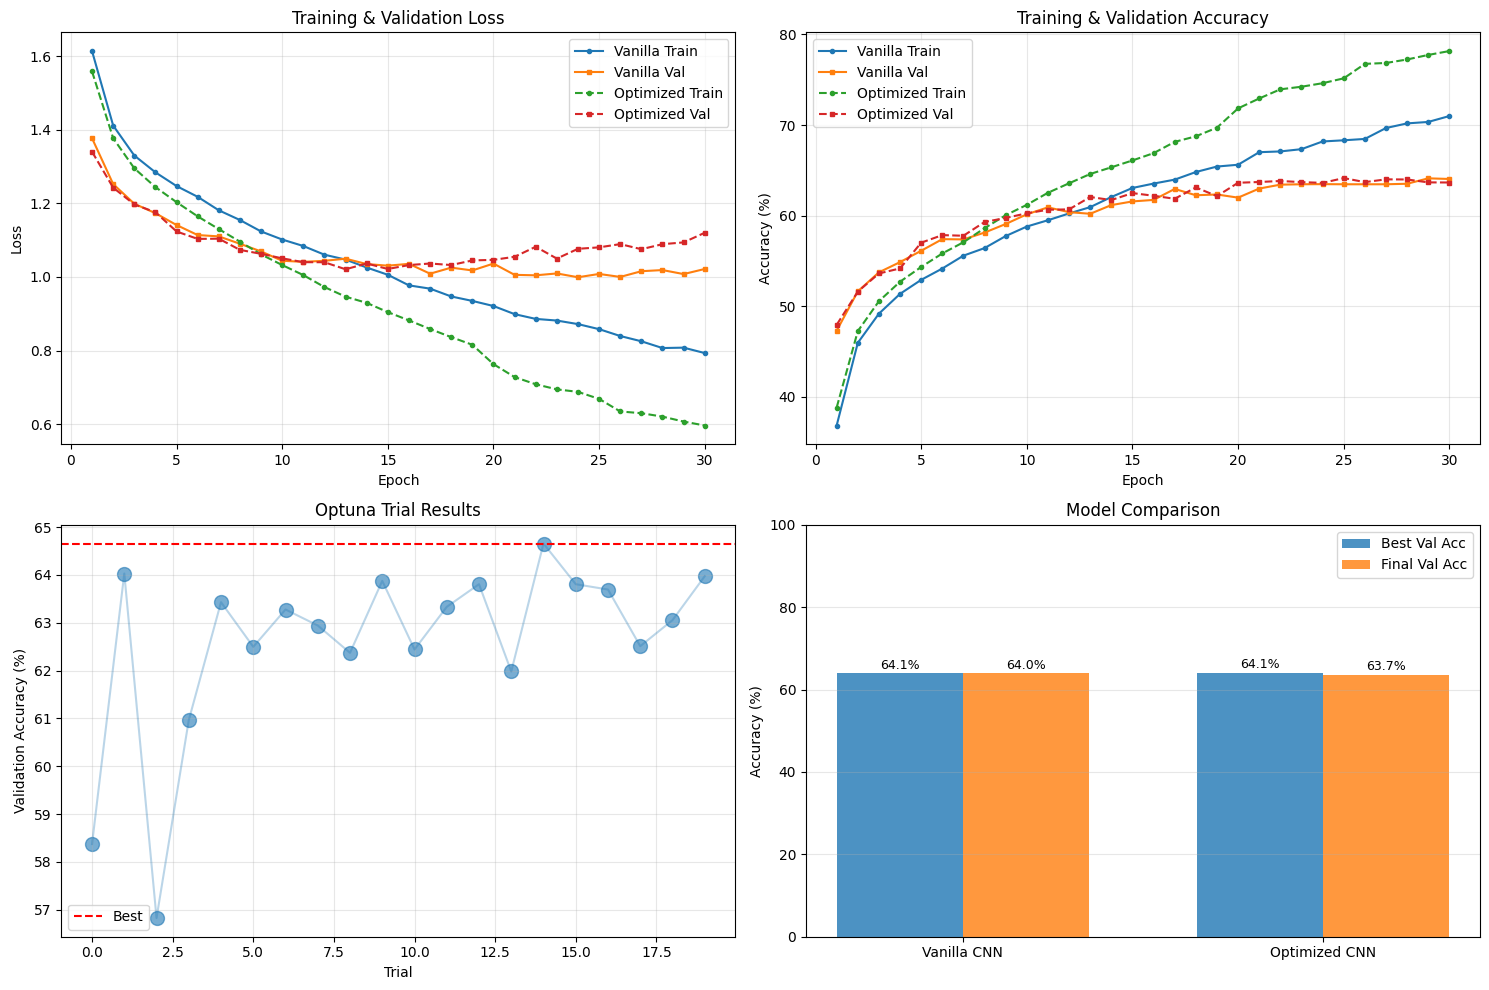


IMPROVEMENT: +0.03%


In [85]:
# Plot both models side by side for comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

epochs_vanilla = range(1, len(history_vanilla['train_losses']) + 1)
epochs_best = range(1, len(history_best['train_losses']) + 1)

axes[0, 0].plot(epochs_vanilla, history_vanilla['train_losses'], label='Vanilla Train', marker='o', markersize=3)
axes[0, 0].plot(epochs_vanilla, history_vanilla['val_losses'], label='Vanilla Val', marker='s', markersize=3)
axes[0, 0].plot(epochs_best, history_best['train_losses'], label='Optimized Train', marker='o', markersize=3, linestyle='--')
axes[0, 0].plot(epochs_best, history_best['val_losses'], label='Optimized Val', marker='s', markersize=3, linestyle='--')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_vanilla, history_vanilla['train_accs'], label='Vanilla Train', marker='o', markersize=3)
axes[0, 1].plot(epochs_vanilla, history_vanilla['val_accs'], label='Vanilla Val', marker='s', markersize=3)
axes[0, 1].plot(epochs_best, history_best['train_accs'], label='Optimized Train', marker='o', markersize=3, linestyle='--')
axes[0, 1].plot(epochs_best, history_best['val_accs'], label='Optimized Val', marker='s', markersize=3, linestyle='--')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training & Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

trials_df = study.trials_dataframe()
axes[1, 0].scatter(range(len(trials_df)), trials_df['value'], alpha=0.6, s=100)
axes[1, 0].plot(range(len(trials_df)), trials_df['value'], alpha=0.3)
axes[1, 0].axhline(y=best_trial.value, color='r', linestyle='--', label='Best')
axes[1, 0].set_xlabel('Trial')
axes[1, 0].set_ylabel('Validation Accuracy (%)')
axes[1, 0].set_title('Optuna Trial Results')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

models = ['Vanilla CNN', 'Optimized CNN']
best_accs = [history_vanilla['best_val_acc'], history_best['best_val_acc']]
final_accs = [history_vanilla['val_accs'][-1], history_best['val_accs'][-1]]

x = np.arange(len(models))
width = 0.35
axes[1, 1].bar(x - width/2, best_accs, width, label='Best Val Acc', alpha=0.8)
axes[1, 1].bar(x + width/2, final_accs, width, label='Final Val Acc', alpha=0.8)
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Model Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models)
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 100])
axes[1, 1].grid(True, alpha=0.3, axis='y')

for i, (best, final) in enumerate(zip(best_accs, final_accs)):
    axes[1, 1].text(i - width/2, best + 1, f'{best:.1f}%', ha='center', fontsize=9)
    axes[1, 1].text(i + width/2, final + 1, f'{final:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

delta = history_best['best_val_acc'] - history_vanilla['best_val_acc']
print("\n" + "="*60)
if delta >= 0:
    print(f"IMPROVEMENT: +{delta:.2f}%")
else:
    print(f"DECLINE: {delta:.2f}% (optimized model was lower than baseline)")
print("="*60)


### Vanilla CNN Model

Batch shape: torch.Size([32, 1, 48, 48])


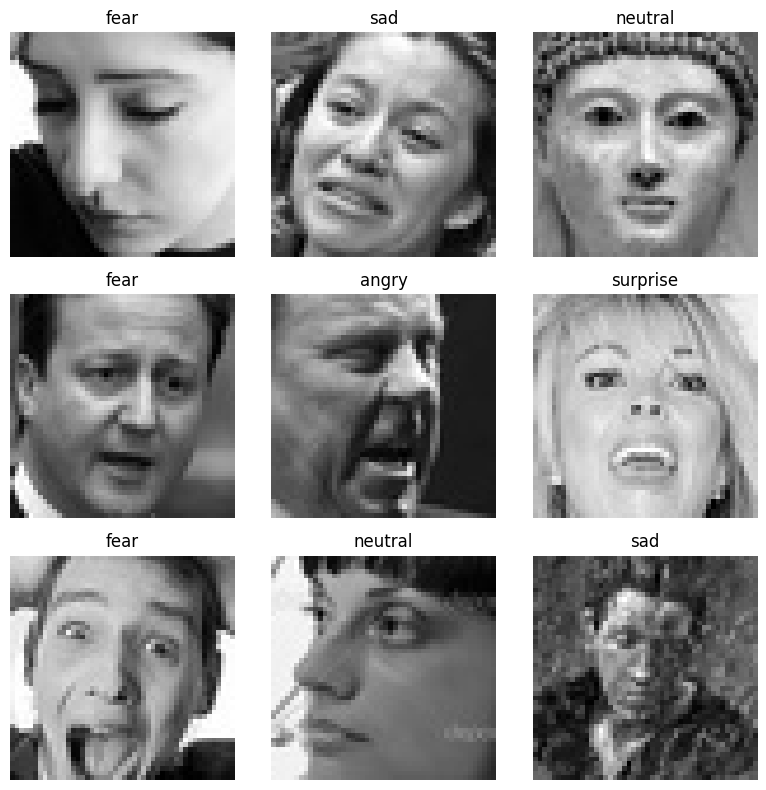

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")

# Visualize first 9 images
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i in range(9):
    ax = axes[i // 3, i % 3]
    img = images[i][0].cpu().numpy()
    label = labels[i].item()
    emotion = train_dataset.classes[label]
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion)
    ax.axis('off')
plt.tight_layout()
plt.show()